In [15]:
import pandas as pd

# 1) Path to your Excel file
file_path = r"D:\VScode\Inso_LGMR\icecore_data\Five_icecore_data.xlsx"

# 2) Read in the workbook
xls = pd.ExcelFile(file_path)

# 3) For each sheet, read it and assign to df_<sheetname>
for sheet in xls.sheet_names:
    # Make a valid Python identifier out of the sheet name
    safe_name = sheet.strip().replace(" ", "_").replace("-", "_")
    df_name = f"df_{safe_name}"
    
    # Load the sheet into a DataFrame
    df = pd.read_excel(xls, sheet_name=sheet)
    
    # Assign it into globals() so you can refer to df_<sheet>
    globals()[df_name] = df
    
    # (Optional) Print confirmation
    print(f"{df_name} → shape {df.shape}")


df_wdc → shape (6373, 2)
df_edml → shape (3350, 2)
df_edc → shape (1648, 2)
df_Fuji → shape (1364, 2)
df_Talos → shape (1671, 2)
df_Five_core → shape (6101, 2)


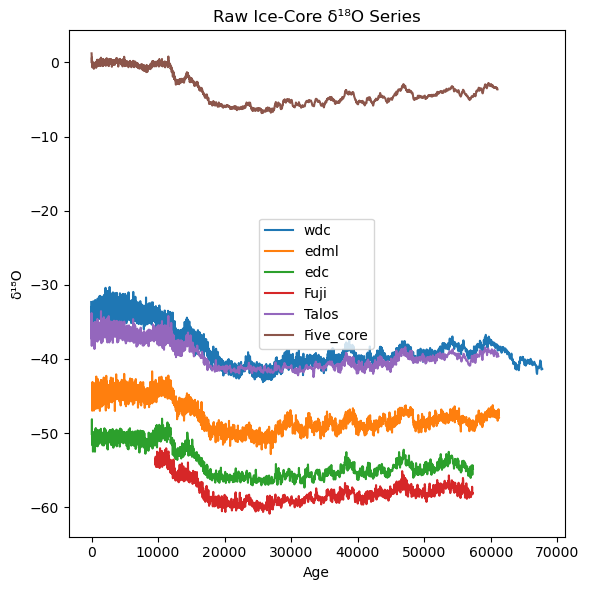

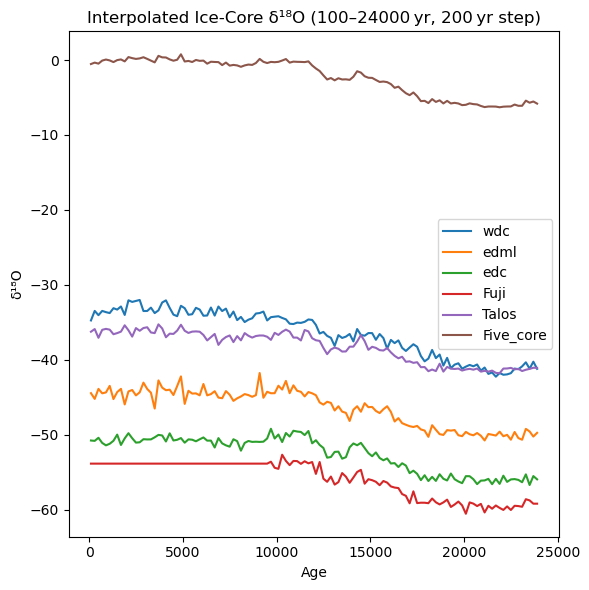

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0) Path to your Excel file
file_path = r"D:\VScode\Inso_LGMR\icecore_data\Five_icecore_data.xlsx"

# 1) Read all sheets into a dict
xls = pd.ExcelFile(file_path)
dfs = {
    sheet: pd.read_excel(xls, sheet_name=sheet)
    for sheet in xls.sheet_names
}

# 2) Plot all raw series
plt.figure(figsize=(6, 6))
for sheet, df in dfs.items():
    plt.plot(df['age'], df['d18O'], label=sheet)
plt.xlabel('Age')
plt.ylabel('δ¹⁸O')
plt.title('Raw Ice‑Core δ¹⁸O Series')
plt.legend()
plt.tight_layout()
plt.show()

# 3) Create new age grid and interpolate each series onto it
new_age = np.arange(100, 24000, 200)  # 100 ≤ age < 24000, step 200
dfs_interp = {}
for sheet, df in dfs.items():
    df_sorted = df.sort_values('age')
    interp_vals = np.interp(new_age,
                            df_sorted['age'],
                            df_sorted['d18O'])
    dfs_interp[sheet] = pd.DataFrame({
        'age': new_age,
        'd18O': interp_vals
    })

# 4) Plot all interpolated series
plt.figure(figsize=(6, 6))
for sheet, dfi in dfs_interp.items():
    plt.plot(dfi['age'], dfi['d18O'], label=sheet)
plt.xlabel('Age')
plt.ylabel('δ¹⁸O')
plt.title('Interpolated Ice‑Core δ¹⁸O (100–24000 yr, 200 yr step)')
plt.legend()
plt.tight_layout()
plt.show()


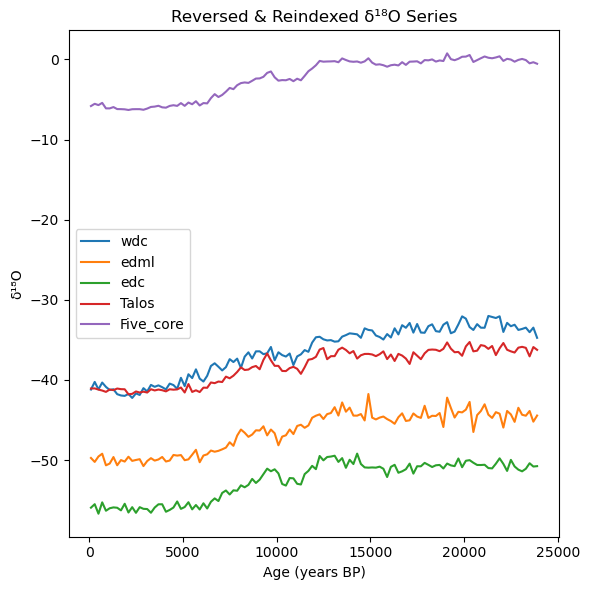

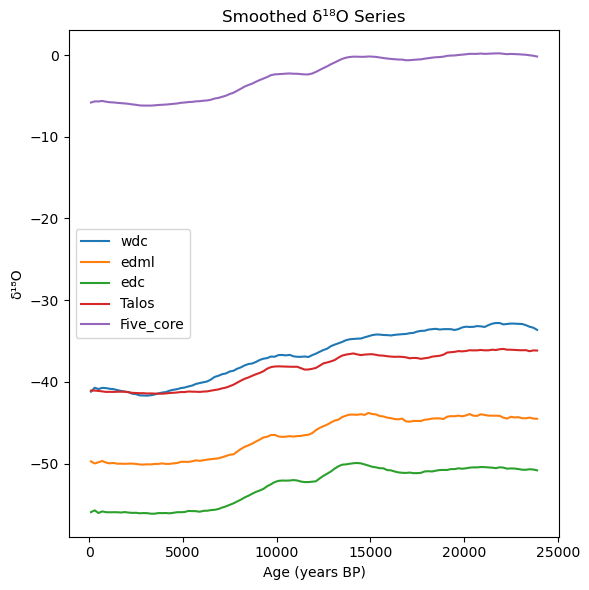

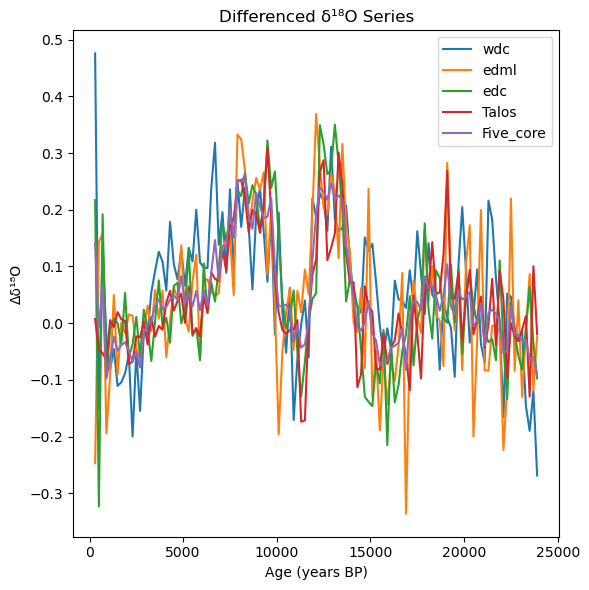

Saved: D:\VScode\Inso_LGMR\icecore_data\wdc_d18O_diff.csv
Saved: D:\VScode\Inso_LGMR\icecore_data\edml_d18O_diff.csv
Saved: D:\VScode\Inso_LGMR\icecore_data\edc_d18O_diff.csv
Saved: D:\VScode\Inso_LGMR\icecore_data\Talos_d18O_diff.csv
Saved: D:\VScode\Inso_LGMR\icecore_data\Five_core_d18O_diff.csv


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. Remove the 'Fuji' series if it exists
dfs_interp.pop('Fuji', None)

# 2. Reverse each series in time, shift age so that 0→24000, then reindex
for name, df in dfs_interp.items():
    # reverse the rows
    df_rev = df.iloc[::-1].copy()
    # shift age: age_rev = -age_orig + 24000
    df_rev['age'] = -df_rev['age'] + 24000
    # reset index so it's 0…N-1
    df_rev.reset_index(drop=True, inplace=True)
    dfs_interp[name] = df_rev

# 2b. Plot all reversed & reindexed series
plt.figure(figsize=(6, 6))
for name, df in dfs_interp.items():
    plt.plot(df['age'], df['d18O'], label=name)
plt.xlabel('Age (years BP)')
plt.ylabel('δ¹⁸O')
plt.title('Reversed & Reindexed δ¹⁸O Series')
plt.legend()
plt.tight_layout()
plt.show()


# smooth the column d18O using a rolling mean with a window of 5

for name, df in dfs_interp.items():
    df['d18O'] = df['d18O'].rolling(window=10, min_periods=1).mean()
    # drop any NaNs that may have been introduced by the rolling mean
    df = df.dropna(subset=['d18O']).reset_index(drop=True)
    dfs_interp[name] = df

plt.figure(figsize=(6, 6))
for name, df in dfs_interp.items():
    plt.plot(df['age'], df['d18O'], label=name)
plt.xlabel('Age (years BP)')
plt.ylabel('δ¹⁸O')
plt.title('Smoothed δ¹⁸O Series')
plt.legend()
plt.tight_layout()
plt.show()


# 3. Compute the first difference of d18O, drop the original column and any NaNs
for name, df in dfs_interp.items():
    df['d18O_diff'] = df['d18O'].diff()
    df = df.drop(columns=['d18O'])
    df = df.dropna(subset=['d18O_diff']).reset_index(drop=True)
    dfs_interp[name] = df

# 3b. Plot the differenced series
plt.figure(figsize=(6, 6))
for name, df in dfs_interp.items():
    plt.plot(df['age'], df['d18O_diff'], label=name)
plt.xlabel('Age (years BP)')
plt.ylabel('Δδ¹⁸O')
plt.title('Differenced δ¹⁸O Series')
plt.legend()
plt.tight_layout()
plt.show()



import os

# Directory where to save the CSVs
out_dir = r"D:\VScode\Inso_LGMR\icecore_data"

for name, df in dfs_interp.items():
    # Construct a safe filename
    safe_name = name.strip().replace(" ", "_")
    filename = f"{safe_name}_d18O_diff.csv"
    filepath = os.path.join(out_dir, filename)
    
    # Save to CSV
    df.to_csv(filepath, index=False)
    
    print(f"Saved: {filepath}")


In [22]:
dfs_interp['edc']

,age,d18O_diff
0,300,0.434012
1,500,-1.186997
2,700,1.415554
3,900,-1.046280
4,1100,0.311280
...,...,...
114,23100,-0.209824
115,23300,0.322716
116,23500,0.686677
117,23700,-0.411251


In [24]:
df_pre

,age,pre
0,300.0,0.017182
1,500.0,0.017535
2,700.0,0.017836
3,900.0,0.018083
4,1100.0,0.018273
...,...,...
114,23100.0,0.017104
115,23300.0,0.017029
116,23500.0,0.016891
117,23700.0,0.016690


In [19]:
import pandas as pd
import importlib
from toolbox import significant_test as st

# Reload in case you’ve tweaked the function
importlib.reload(st)

# 1) Load your precession data once
df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")

# 2) For each differenced ice‑core series in dfs_interp…
results = {}
for core_name, df_diff in dfs_interp.items():
    # build the merged DataFrame
    df_merged = pd.DataFrame({
        'age':       df_diff['age'].values,
        'diff_temp': df_diff['d18O_diff'].values,
        'pre':       df_pre['pre'].values
    })

    # 3) Run unidirectional CCM test: diff_temp → pre
    ccm_out, ran_ccm_list, test_result = st.ccm_significance_test_v2_df(
        df_input   = df_merged,
        E          = 5,
        tau        = -3,
        Tp         = 0,
        n_ran      = 100,
        libSizes   = "10 20 30 40 50 60 70 80",
        random     = True,
        sample     = 20,
        showPlot   = False   # turn off individual plots
    )

    # store and print
    results[core_name] = test_result
    print(f"{core_name}: unidirectional causality pre → diff_temp? {test_result}")

# 4) Optionally, collect and display in a DataFrame
df_results = pd.DataFrame.from_dict(
    results, orient='index', columns=['Temp_xmap_pre', 'pre_xmap_Temp']
)
print("\nSummary of causality tests:")
print(df_results)


wdc: unidirectional causality pre → diff_temp? (False, True)
edml: unidirectional causality pre → diff_temp? (True, False)
edc: unidirectional causality pre → diff_temp? (True, True)
Talos: unidirectional causality pre → diff_temp? (True, False)
Five_core: unidirectional causality pre → diff_temp? (True, False)

Summary of causality tests:
           Temp_xmap_pre  pre_xmap_Temp
wdc                False           True
edml                True          False
edc                 True           True
Talos               True          False
Five_core           True          False


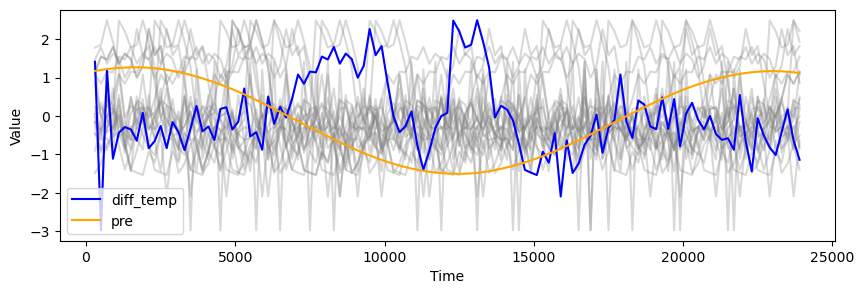

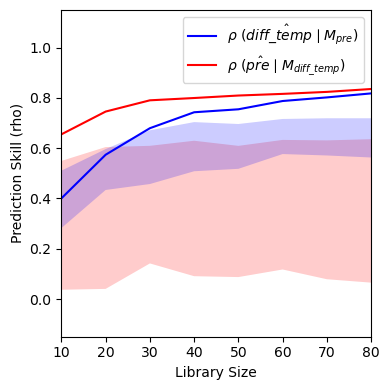

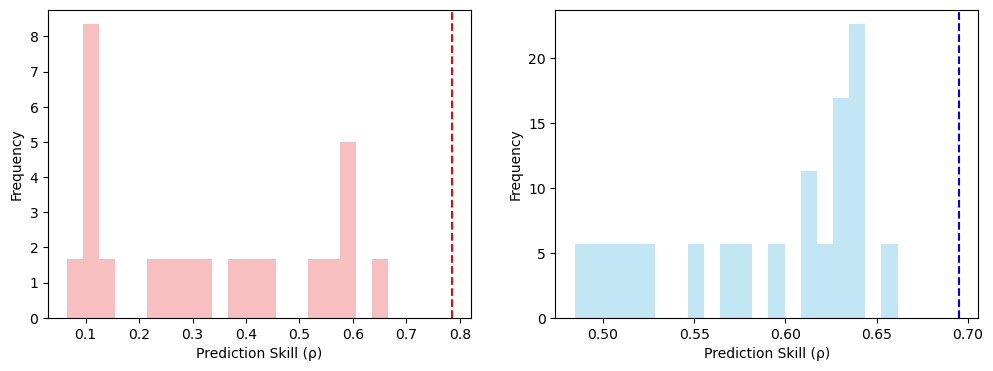

(True, True)


In [20]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)


df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")

df_merged = pd.DataFrame({
    'age':       dfs_interp['edc']['age'].values,
    'diff_temp': dfs_interp['edc']['d18O_diff'].values,
    'pre':       df_pre['pre'].values
})


ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v2_df(
    df_input      = df_merged,
    E         = 5,
    tau       = -3,
    Tp =0,
    n_ran     = 20,
    libSizes  = "10 20 30 40 50 60 70 80",
    random=True,
    sample    = 10,
    showPlot  = True
)

# print test_result
print(test_result)

In [24]:
import pandas as pd
import importlib
from toolbox import significant_test as st

# Reload in case you’ve tweaked the function
importlib.reload(st)

# 1) Load your precession data once
df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")

# 2) For each differenced ice‑core series in dfs_interp…
results = {}
for core_name, df_diff in dfs_interp.items():
    # build the merged DataFrame
    df_merged = pd.DataFrame({
        'age':       df_diff['age'].values,
        'diff_temp': df_diff['d18O_diff'].values,
        'pre':       df_pre['pre'].values
    })

    # 3) Run unidirectional CCM test: diff_temp → pre
    ccm_out, ran_ccm_list, test_result = st.ccm_significance_test_v3_df(
        df_input   = df_merged,
        E          = 5,
        tau        = -3,
        Tp         = 0,
        n_ran      = 100,
        libSizes   = "10 20 30 40 50 60 70 80",
        random     = True,
        sample     = 20,
        showPlot   = False   # turn off individual plots
    )

    # store and print
    results[core_name] = test_result
    print(f"{core_name}: unidirectional causality pre → diff_temp? {test_result}")

# 4) Optionally, collect and display in a DataFrame
df_results = pd.DataFrame.from_dict(
    results, orient='index', columns=['Temp_xmap_pre', 'pre_xmap_Temp']
)
print("\nSummary of causality tests:")
print(df_results)


wdc: unidirectional causality pre → diff_temp? (False, True)
edml: unidirectional causality pre → diff_temp? (True, False)
edc: unidirectional causality pre → diff_temp? (True, True)
Talos: unidirectional causality pre → diff_temp? (False, False)
Five_core: unidirectional causality pre → diff_temp? (False, False)

Summary of causality tests:
           Temp_xmap_pre  pre_xmap_Temp
wdc                False           True
edml                True          False
edc                 True           True
Talos              False          False
Five_core          False          False
